In this notebook, we demonstrate the empirical performance of the Universal Portfolio algorithm on real stock data.

We use the `uni_port_func` function implemented in `src.jl`. The dataset we used is `prices_4stocks.csv`, the time horizon is one-year period.

In [4]:
using CSV
using DataFrames
using Plots
using LinearAlgebra
using Revise
includet("../src.jl")

price_df= CSV.read("../dataset/prices_4stocks.csv", DataFrame)
println(size(price_df))
println(first(price_df, 5))
println(names(price_df))

(250, 5)
5×5 DataFrame
 Row │ Date        AAPL     KO       TSLA     WMT     
     │ Date        Float64  Float64  Float64  Float64 
─────┼────────────────────────────────────────────────
   1 │ 2025-01-02  242.525  59.6576   379.28  88.9641
   2 │ 2025-01-03  242.038  59.5708   410.44  89.7351
   3 │ 2025-01-06  243.669  58.664    411.05  90.3776
   4 │ 2025-01-07  240.894  58.6929   394.36  89.7648
   5 │ 2025-01-08  241.381  59.5322   394.94  90.7434
["Date", "AAPL", "KO", "TSLA", "WMT"]


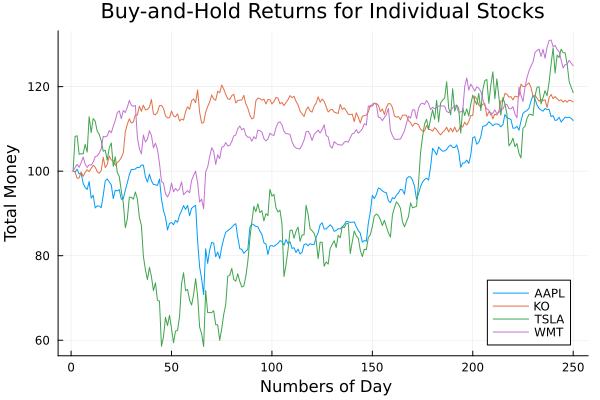

Stock columns: ["AAPL", "KO", "TSLA", "WMT"]
Price matrix size: (250, 4)


In [ ]:
init_money= 100.0
stock_cols= names(price_df)[2:end]
prices= Matrix{Float64}(select(price_df,stock_cols)) # we store the stock_cols as prices
println("Stock columns: ", stock_cols)
println("Price matrix size: ", size(prices))
# for each stock we compute wealth trajectory for buy and hold strategy
buy_hold= init_money.*(prices./reshape(prices[1,:],1,:))
p1= plot(title="Buy-and-Hold Returns for Individual Stocks",xlabel=" Numbers of Day",ylabel= "Total Money")
for i in 1:length(stock_cols) # we plot buy-and-hold wealth trajectory for each stock
    plot!(p1,buy_hold[:, i],label = stock_cols[i])
end
display(p1)
